In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import time
import warnings

warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate
)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# Models
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

# XGBoost
from xgboost import XGBClassifier

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# Column names for WDBC dataset

columns = [
    "ID",
    "Diagnosis",

    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",

    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave_points_se",
    "symmetry_se",
    "fractal_dimension_se",

    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave_points_worst",
    "symmetry_worst",
    "fractal_dimension_worst"
]

# Load dataset
data = pd.read_csv(
    "wdbc.data",
    header=None,
    names=columns
)

print("Dataset loaded successfully!")

print("\nDataset shape:")
print(data.shape)

print("\nFirst 5 rows:")
display(data.head())

Dataset loaded successfully!

Dataset shape:
(569, 32)

First 5 rows:


,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
# Separate features and target

X = data.drop(
    columns=["ID", "Diagnosis"]
)

y = data["Diagnosis"].map({
    "M": 0,
    "B": 1
})

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget classes:")
print(y.unique())

Number of samples: 569
Number of features: 30

X shape: (569, 30)
y shape: (569,)

Target classes:
[0 1]


In [6]:
print("Dataset Information")
print("=" * 50)

print("Number of samples :", X.shape[0])
print("Number of features:", X.shape[1])

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(
    y.value_counts(normalize=True) * 100
)

Dataset Information
Number of samples : 569
Number of features: 30

Target distribution:
Diagnosis
1    357
0    212
Name: count, dtype: int64

Target percentage:
Diagnosis
1    62.741652
0    37.258348
Name: proportion, dtype: float64


In [7]:
print("Missing values in dataset:")
print(X.isnull().sum().sum())

Missing values in dataset:
0


In [8]:
print("Duplicate rows:", X.duplicated().sum())

Duplicate rows: 0


In [9]:
X.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


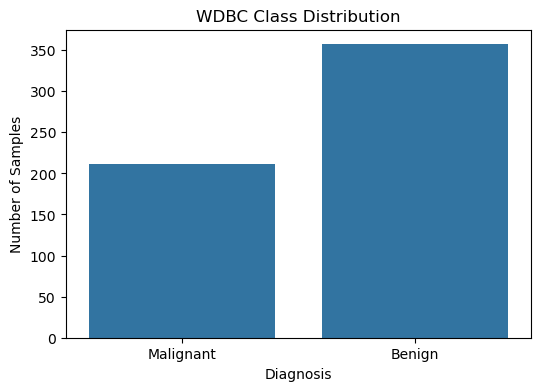

In [10]:
plt.figure(figsize=(6, 4))

sns.countplot(
    x=y.map({
        0: "Malignant",
        1: "Benign"
    })
)

plt.title("WDBC Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")

plt.show()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 455
Testing samples : 114


In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Standardization completed!")

Standardization completed!


In [13]:
pca_full = PCA()

X_train_pca_full = pca_full.fit_transform(
    X_train_scaled
)

explained_variance = (
    pca_full.explained_variance_ratio_
)

cumulative_variance = np.cumsum(
    explained_variance
)

print("Explained variance:")
print(explained_variance)

print("\nCumulative explained variance:")
print(cumulative_variance)

Explained variance:
[4.44134918e-01 1.89446183e-01 9.54335633e-02 6.72468941e-02
 5.51769040e-02 3.93453424e-02 2.18176591e-02 1.58331722e-02
 1.27878330e-02 1.14544250e-02 9.26269214e-03 8.47428916e-03
 7.99746679e-03 5.30706257e-03 3.12250212e-03 2.57146110e-03
 2.03925720e-03 1.86696858e-03 1.49100638e-03 1.03671459e-03
 9.25703045e-04 8.66421035e-04 7.19778970e-04 5.88332657e-04
 5.04652748e-04 2.45507775e-04 2.16103111e-04 5.71732867e-05
 2.57352579e-05 4.27774949e-06]

Cumulative explained variance:
[0.44413492 0.6335811  0.72901466 0.79626156 0.85143846 0.8907838
 0.91260146 0.92843464 0.94122247 0.95267689 0.96193959 0.97041388
 0.97841134 0.9837184  0.98684091 0.98941237 0.99145162 0.99331859
 0.9948096  0.99584631 0.99677202 0.99763844 0.99835822 0.99894655
 0.9994512  0.99969671 0.99991281 0.99996999 0.99999572 1.        ]


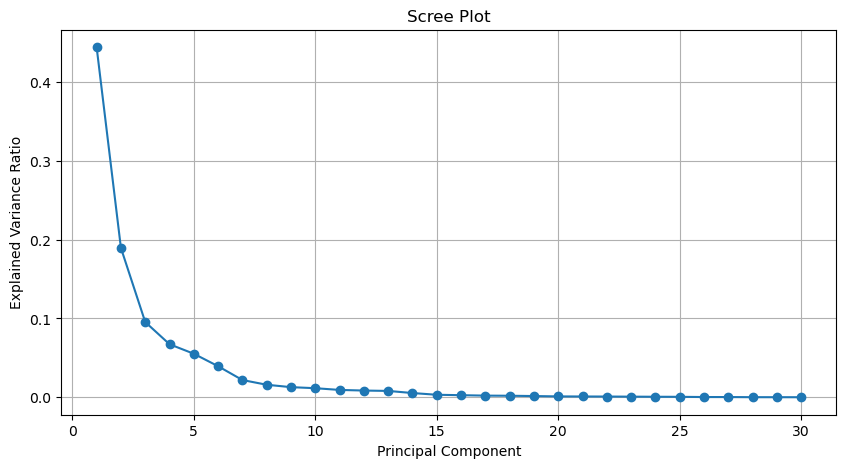

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")

plt.grid(True)

plt.show()

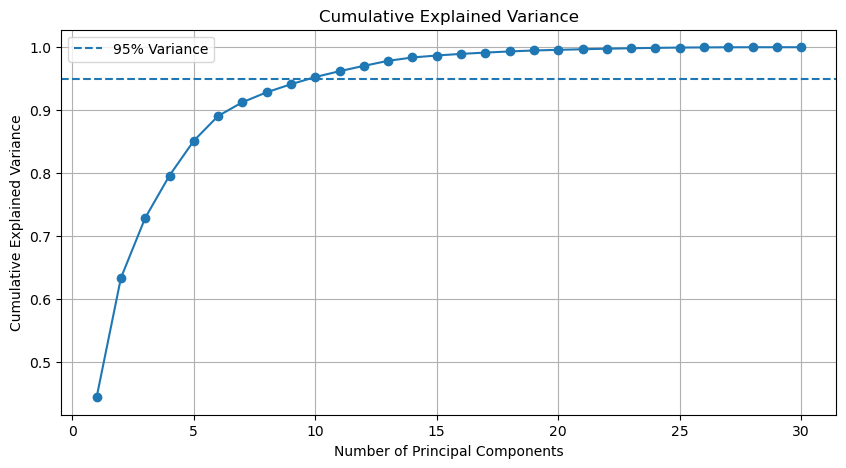

In [15]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% Variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.legend()
plt.grid(True)

plt.show()

In [16]:
n_components = (
    np.argmax(
        cumulative_variance >= 0.95
    ) + 1
)

print(
    "Number of components required:",
    n_components
)

print(
    "Explained variance:",
    cumulative_variance[n_components - 1] * 100,
    "%"
)

Number of components required: 10
Explained variance: 95.26768937417546 %


In [17]:
pca_summary = pd.DataFrame({
    "Setting": ["With PCA"],
    "Original Features": [X.shape[1]],
    "Chosen Components": [n_components],
    "Variance Target": ["95%"],
    "Actual Explained Variance (%)": [
        cumulative_variance[n_components - 1] * 100
    ],
    "Reduction (%)": [
        (1 - n_components / X.shape[1]) * 100
    ]
})

display(pca_summary)

,Setting,Original Features,Chosen Components,Variance Target,Actual Explained Variance (%),Reduction (%)
0,With PCA,30,10,95%,95.267689,66.666667


In [18]:
pca = PCA(
    n_components=n_components
)

X_train_pca = pca.fit_transform(
    X_train_scaled
)

X_test_pca = pca.transform(
    X_test_scaled
)

print("Original number of features:",
      X_train_scaled.shape[1])

print("Reduced number of features:",
      X_train_pca.shape[1])

Original number of features: 30
Reduced number of features: 10


In [19]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold Stratified Cross-Validation created.")

5-Fold Stratified Cross-Validation created.


In [20]:
models = {

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "Naive Bayes": GaussianNB(),

    "KNN": KNeighborsClassifier(),

    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )
}

print("Models created:")
for name in models:
    print("-", name)

Models created:
- SVM
- Naive Bayes
- KNN
- Logistic Regression
- Decision Tree
- Random Forest
- AdaBoost
- Gradient Boosting
- XGBoost


In [21]:
param_grids = {

    "SVM": {
        "C": [0.1, 1, 10, 100],
        "gamma": ["scale", 0.01, 0.1, 1],
        "kernel": ["rbf", "linear"]
    },

    "Naive Bayes": {
        "var_smoothing": [
            1e-11,
            1e-10,
            1e-9,
            1e-8,
            1e-7
        ]
    },

    "KNN": {
        "n_neighbors": [3, 5, 7, 9, 11],
        "weights": [
            "uniform",
            "distance"
        ],
        "metric": [
            "euclidean",
            "manhattan"
        ]
    },

    "Logistic Regression": {
        "C": [
            0.01,
            0.1,
            1,
            10,
            100
        ],
        "solver": ["liblinear"]
    },

    "Decision Tree": {
        "max_depth": [
            None,
            3,
            5,
            10,
            15
        ],
        "min_samples_split": [
            2,
            5,
            10
        ],
        "criterion": [
            "gini",
            "entropy"
        ]
    },

    "Random Forest": {
        "n_estimators": [
            50,
            100,
            200
        ],
        "max_depth": [
            None,
            5,
            10,
            15
        ],
        "min_samples_split": [
            2,
            5
        ]
    },

    "AdaBoost": {
        "n_estimators": [
            50,
            100,
            200
        ],
        "learning_rate": [
            0.01,
            0.1,
            1.0
        ]
    },

    "Gradient Boosting": {
        "n_estimators": [
            50,
            100,
            200
        ],
        "learning_rate": [
            0.01,
            0.1,
            0.2
        ],
        "max_depth": [
            2,
            3,
            5
        ]
    },

    "XGBoost": {
        "n_estimators": [
            50,
            100,
            200
        ],
        "max_depth": [
            3,
            5,
            7
        ],
        "learning_rate": [
            0.01,
            0.1,
            0.2
        ]
    }
}

In [22]:
def tune_model(
    model,
    param_grid,
    X_data,
    y_data
):

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    start = time.time()

    grid.fit(
        X_data,
        y_data
    )

    end = time.time()

    print(
        "Best Parameters:",
        grid.best_params_
    )

    print(
        "Best CV F1:",
        round(grid.best_score_, 4)
    )

    print(
        "Time:",
        round(end - start, 2),
        "seconds"
    )

    return grid.best_estimator_

In [23]:
best_models_no_pca = {}

for name in models:

    print("\n")
    print("=" * 60)
    print("Tuning:", name)
    print("Setting: NO PCA")
    print("=" * 60)

    best_models_no_pca[name] = tune_model(
        models[name],
        param_grids[name],
        X_train_scaled,
        y_train
    )



Tuning: SVM
Setting: NO PCA
Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV F1: 0.981
Time: 10.94 seconds


Tuning: Naive Bayes
Setting: NO PCA
Best Parameters: {'var_smoothing': 1e-11}
Best CV F1: 0.9478
Time: 0.09 seconds


Tuning: KNN
Setting: NO PCA
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
Best CV F1: 0.9774
Time: 0.65 seconds


Tuning: Logistic Regression
Setting: NO PCA
Best Parameters: {'C': 1, 'solver': 'liblinear'}
Best CV F1: 0.9842
Time: 0.12 seconds


Tuning: Decision Tree
Setting: NO PCA
Best Parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
Best CV F1: 0.9464
Time: 0.86 seconds


Tuning: Random Forest
Setting: NO PCA
Best Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1: 0.9702
Time: 13.91 seconds


Tuning: AdaBoost
Setting: NO PCA
Best Parameters: {'learning_rate': 1.0, 'n_estimators': 100}
Best CV F1: 0.9844
Time: 10.52 seconds


Tuning: Gra

In [24]:
best_models_pca = {}

for name in models:

    print("\n")
    print("=" * 60)
    print("Tuning:", name)
    print("Setting: WITH PCA")
    print("=" * 60)

    best_models_pca[name] = tune_model(
        models[name],
        param_grids[name],
        X_train_pca,
        y_train
    )



Tuning: SVM
Setting: WITH PCA
Best Parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV F1: 0.9845
Time: 2.98 seconds


Tuning: Naive Bayes
Setting: WITH PCA
Best Parameters: {'var_smoothing': 1e-11}
Best CV F1: 0.9347
Time: 0.09 seconds


Tuning: KNN
Setting: WITH PCA
Best Parameters: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Best CV F1: 0.9724
Time: 0.4 seconds


Tuning: Logistic Regression
Setting: WITH PCA
Best Parameters: {'C': 1, 'solver': 'liblinear'}
Best CV F1: 0.9861
Time: 0.12 seconds


Tuning: Decision Tree
Setting: WITH PCA
Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 10}
Best CV F1: 0.9522
Time: 0.68 seconds


Tuning: Random Forest
Setting: WITH PCA
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1: 0.9687
Time: 15.34 seconds


Tuning: AdaBoost
Setting: WITH PCA
Best Parameters: {'learning_rate': 1.0, 'n_estimators': 200}
Best CV F1: 0.9622
Time: 13.14 seconds


In [28]:
def create_stacking_model():

    base_learners = [

        (
            "svm",
            SVC(
                C=1,
                probability=True,
                random_state=42
            )
        ),

        (
            "knn",
            KNeighborsClassifier(
                n_neighbors=5
            )
        ),

        (
            "rf",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ]

    meta_learner = LogisticRegression(
        max_iter=5000
    )

    stacking = StackingClassifier(
        estimators=base_learners,
        final_estimator=meta_learner,
        cv=5
    )

    return stacking

In [29]:
stacking_no_pca = create_stacking_model()

stacking_no_pca.fit(
    X_train_scaled,
    y_train
)

print("Stacking trained without PCA.")

Stacking trained without PCA.


In [30]:
stacking_pca = create_stacking_model()

stacking_pca.fit(
    X_train_pca,
    y_train
)

print("Stacking trained with PCA.")

Stacking trained with PCA.


In [31]:
best_models_no_pca["Stacking"] = stacking_no_pca

best_models_pca["Stacking"] = stacking_pca

In [32]:
def evaluate_model(
    model,
    X_test_data,
    y_test_data
):

    y_pred = model.predict(
        X_test_data
    )

    accuracy = accuracy_score(
        y_test_data,
        y_pred
    )

    precision = precision_score(
        y_test_data,
        y_pred
    )

    recall = recall_score(
        y_test_data,
        y_pred
    )

    f1 = f1_score(
        y_test_data,
        y_pred
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

In [33]:
results_no_pca = {}

for name, model in best_models_no_pca.items():

    results_no_pca[name] = evaluate_model(
        model,
        X_test_scaled,
        y_test
    )

results_no_pca_df = pd.DataFrame(
    results_no_pca
).T

display(results_no_pca_df)

,Accuracy,Precision,Recall,F1 Score
SVM,0.982456,0.986111,0.986111,0.986111
Naive Bayes,0.929825,0.944444,0.944444,0.944444
KNN,0.964912,0.959459,0.986111,0.972603
Logistic Regression,0.982456,0.986111,0.986111,0.986111
Decision Tree,0.947368,0.945946,0.972222,0.958904
Random Forest,0.956140,0.958904,0.972222,0.965517
AdaBoost,0.956140,0.946667,0.986111,0.965986
Gradient Boosting,0.956140,0.946667,0.986111,0.965986
XGBoost,0.947368,0.945946,0.972222,0.958904
Stacking,0.973684,0.985915,0.972222,0.979021


In [34]:
results_pca = {}

for name, model in best_models_pca.items():

    results_pca[name] = evaluate_model(
        model,
        X_test_pca,
        y_test
    )

results_pca_df = pd.DataFrame(
    results_pca
).T

display(results_pca_df)

,Accuracy,Precision,Recall,F1 Score
SVM,0.956140,0.985507,0.944444,0.964539
Naive Bayes,0.921053,0.931507,0.944444,0.937931
KNN,0.956140,0.958904,0.972222,0.965517
Logistic Regression,0.964912,0.985714,0.958333,0.971831
Decision Tree,0.929825,0.944444,0.944444,0.944444
Random Forest,0.938596,0.957746,0.944444,0.951049
AdaBoost,0.938596,0.957746,0.944444,0.951049
Gradient Boosting,0.947368,0.945946,0.972222,0.958904
XGBoost,0.947368,0.958333,0.958333,0.958333
Stacking,0.956140,0.971831,0.958333,0.965035


In [35]:
comparison = pd.DataFrame({

    "No PCA Accuracy":
        results_no_pca_df["Accuracy"],

    "PCA Accuracy":
        results_pca_df["Accuracy"],

    "No PCA Precision":
        results_no_pca_df["Precision"],

    "PCA Precision":
        results_pca_df["Precision"],

    "No PCA Recall":
        results_no_pca_df["Recall"],

    "PCA Recall":
        results_pca_df["Recall"],

    "No PCA F1":
        results_no_pca_df["F1 Score"],

    "PCA F1":
        results_pca_df["F1 Score"]
})

display(comparison)

,No PCA Accuracy,PCA Accuracy,No PCA Precision,PCA Precision,No PCA Recall,PCA Recall,No PCA F1,PCA F1
SVM,0.982456,0.956140,0.986111,0.985507,0.986111,0.944444,0.986111,0.964539
Naive Bayes,0.929825,0.921053,0.944444,0.931507,0.944444,0.944444,0.944444,0.937931
KNN,0.964912,0.956140,0.959459,0.958904,0.986111,0.972222,0.972603,0.965517
Logistic Regression,0.982456,0.964912,0.986111,0.985714,0.986111,0.958333,0.986111,0.971831
Decision Tree,0.947368,0.929825,0.945946,0.944444,0.972222,0.944444,0.958904,0.944444
Random Forest,0.956140,0.938596,0.958904,0.957746,0.972222,0.944444,0.965517,0.951049
AdaBoost,0.956140,0.938596,0.946667,0.957746,0.986111,0.944444,0.965986,0.951049
Gradient Boosting,0.956140,0.947368,0.946667,0.945946,0.986111,0.972222,0.965986,0.958904
XGBoost,0.947368,0.947368,0.945946,0.958333,0.972222,0.958333,0.958904,0.958333
Stacking,0.973684,0.956140,0.985915,0.971831,0.972222,0.958333,0.979021,0.965035


In [36]:
comparison["Accuracy Change"] = (
    comparison["PCA Accuracy"]
    -
    comparison["No PCA Accuracy"]
)

comparison["F1 Change"] = (
    comparison["PCA F1"]
    -
    comparison["No PCA F1"]
)

display(comparison)

,No PCA Accuracy,PCA Accuracy,No PCA Precision,PCA Precision,No PCA Recall,PCA Recall,No PCA F1,PCA F1,Accuracy Change,F1 Change
SVM,0.982456,0.956140,0.986111,0.985507,0.986111,0.944444,0.986111,0.964539,-0.026316,-0.021572
Naive Bayes,0.929825,0.921053,0.944444,0.931507,0.944444,0.944444,0.944444,0.937931,-0.008772,-0.006513
KNN,0.964912,0.956140,0.959459,0.958904,0.986111,0.972222,0.972603,0.965517,-0.008772,-0.007085
Logistic Regression,0.982456,0.964912,0.986111,0.985714,0.986111,0.958333,0.986111,0.971831,-0.017544,-0.014280
Decision Tree,0.947368,0.929825,0.945946,0.944444,0.972222,0.944444,0.958904,0.944444,-0.017544,-0.014460
Random Forest,0.956140,0.938596,0.958904,0.957746,0.972222,0.944444,0.965517,0.951049,-0.017544,-0.014468
AdaBoost,0.956140,0.938596,0.946667,0.957746,0.986111,0.944444,0.965986,0.951049,-0.017544,-0.014937
Gradient Boosting,0.956140,0.947368,0.946667,0.945946,0.986111,0.972222,0.965986,0.958904,-0.008772,-0.007082
XGBoost,0.947368,0.947368,0.945946,0.958333,0.972222,0.958333,0.958904,0.958333,0.000000,-0.000571
Stacking,0.973684,0.956140,0.985915,0.971831,0.972222,0.958333,0.979021,0.965035,-0.017544,-0.013986


In [37]:
def get_cv_scores(
    model,
    X_data,
    y_data
):

    scores = cross_validate(
        model,
        X_data,
        y_data,
        cv=cv,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1"
        ],
        n_jobs=-1
    )

    return {
        "accuracy": scores["test_accuracy"],
        "precision": scores["test_precision"],
        "recall": scores["test_recall"],
        "f1": scores["test_f1"]
    }

In [38]:
cv_results_no_pca = {}

for name, model in best_models_no_pca.items():

    print("Cross-validating:", name)

    cv_results_no_pca[name] = get_cv_scores(
        model,
        X_train_scaled,
        y_train
    )

Cross-validating: SVM
Cross-validating: Naive Bayes
Cross-validating: KNN
Cross-validating: Logistic Regression
Cross-validating: Decision Tree
Cross-validating: Random Forest
Cross-validating: AdaBoost
Cross-validating: Gradient Boosting
Cross-validating: XGBoost
Cross-validating: Stacking


In [39]:
cv_results_pca = {}

for name, model in best_models_pca.items():

    print("Cross-validating:", name)

    cv_results_pca[name] = get_cv_scores(
        model,
        X_train_pca,
        y_train
    )

Cross-validating: SVM
Cross-validating: Naive Bayes
Cross-validating: KNN
Cross-validating: Logistic Regression
Cross-validating: Decision Tree
Cross-validating: Random Forest
Cross-validating: AdaBoost
Cross-validating: Gradient Boosting
Cross-validating: XGBoost
Cross-validating: Stacking


In [40]:
cv_table = []

for name in best_models_no_pca.keys():

    no_pca_f1 = cv_results_no_pca[name]["f1"]
    pca_f1 = cv_results_pca[name]["f1"]

    cv_table.append([
        name,

        no_pca_f1[0],
        no_pca_f1[1],
        no_pca_f1[2],
        no_pca_f1[3],
        no_pca_f1[4],

        np.mean(no_pca_f1),
        np.mean(pca_f1)
    ])

cv_table_df = pd.DataFrame(
    cv_table,
    columns=[
        "Model",
        "Fold 1",
        "Fold 2",
        "Fold 3",
        "Fold 4",
        "Fold 5",
        "Avg No-PCA",
        "Avg PCA"
    ]
)

display(cv_table_df)

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Avg No-PCA,Avg PCA
0,SVM,0.966102,0.982456,0.982456,0.982759,0.991304,0.981015,0.984463
1,Naive Bayes,0.931034,0.973451,0.912281,0.965517,0.956522,0.947761,0.934674
2,KNN,0.982759,0.991304,0.964912,0.965517,0.982456,0.977390,0.972380
3,Logistic Regression,0.982759,0.991150,0.982456,0.991304,0.973451,0.984224,0.986086
4,Decision Tree,0.925620,0.954955,0.928571,0.949153,0.973451,0.946350,0.952174
5,Random Forest,0.965517,0.973451,0.946429,0.974359,0.991150,0.970181,0.968660
6,AdaBoost,0.991304,1.000000,0.956522,0.982759,0.991304,0.984378,0.962209
7,Gradient Boosting,0.982759,0.991304,0.964912,0.965517,0.991304,0.979159,0.972043
8,XGBoost,0.991304,0.982456,0.955752,0.965517,0.991150,0.977236,0.973878
9,Stacking,0.982759,0.973913,0.964286,0.973913,0.991304,0.977235,0.977389


In [41]:
stability_table = []

for name in best_models_no_pca.keys():

    no_pca_std = np.std(
        cv_results_no_pca[name]["f1"]
    )

    pca_std = np.std(
        cv_results_pca[name]["f1"]
    )

    stability_table.append([
        name,
        no_pca_std,
        pca_std,
        pca_std < no_pca_std
    ])

stability_df = pd.DataFrame(
    stability_table,
    columns=[
        "Model",
        "No-PCA F1 Std",
        "PCA F1 Std",
        "PCA More Stable?"
    ]
)

display(stability_df)

,Model,No-PCA F1 Std,PCA F1 Std,PCA More Stable?
0,SVM,0.008191,0.009793,False
1,Naive Bayes,0.022762,0.014928,True
2,KNN,0.010438,0.012631,False
3,Logistic Regression,0.006625,0.004200,True
4,Decision Tree,0.017676,0.026841,False
5,Random Forest,0.014518,0.014108,True
6,AdaBoost,0.014957,0.011155,True
7,Gradient Boosting,0.011807,0.017139,False
8,XGBoost,0.014266,0.012115,True
9,Stacking,0.009146,0.008902,True


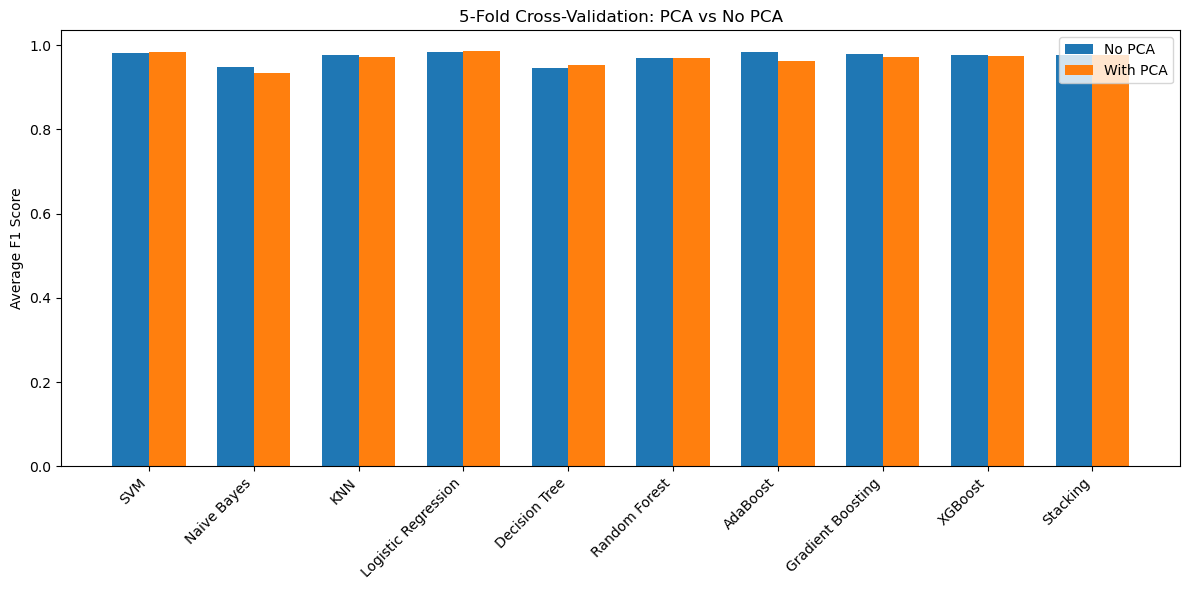

In [42]:
plt.figure(figsize=(12, 6))

x = np.arange(
    len(cv_table_df)
)

width = 0.35

plt.bar(
    x - width / 2,
    cv_table_df["Avg No-PCA"],
    width,
    label="No PCA"
)

plt.bar(
    x + width / 2,
    cv_table_df["Avg PCA"],
    width,
    label="With PCA"
)

plt.xticks(
    x,
    cv_table_df["Model"],
    rotation=45,
    ha="right"
)

plt.ylabel("Average F1 Score")
plt.title(
    "5-Fold Cross-Validation: PCA vs No PCA"
)

plt.legend()

plt.tight_layout()

plt.show()

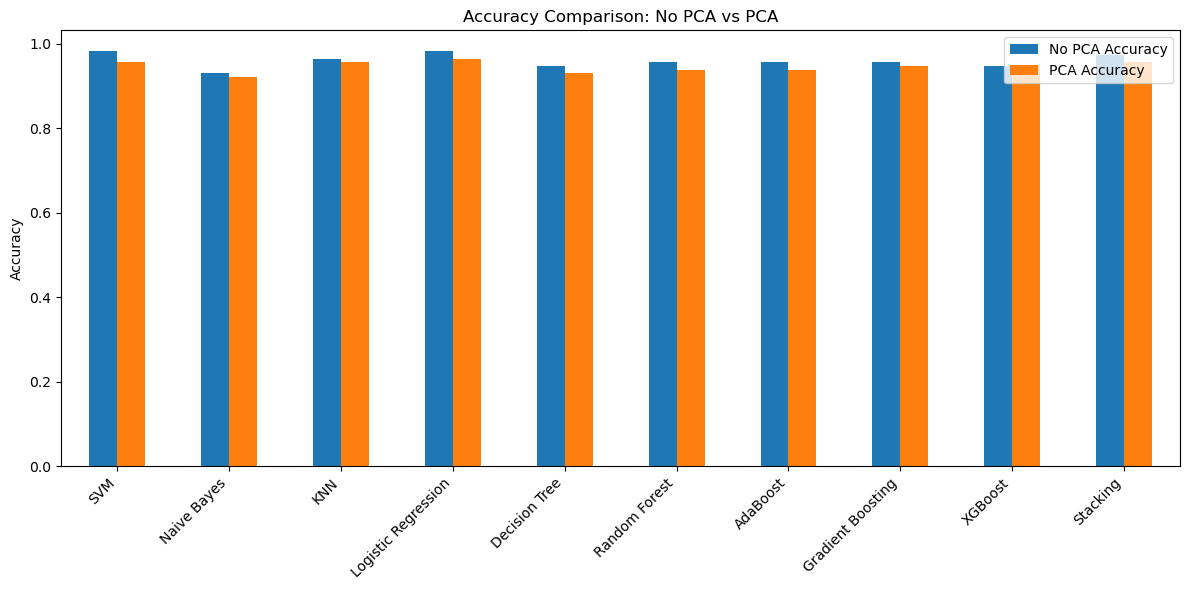

In [43]:
comparison[
    [
        "No PCA Accuracy",
        "PCA Accuracy"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.ylabel("Accuracy")
plt.title(
    "Accuracy Comparison: No PCA vs PCA"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

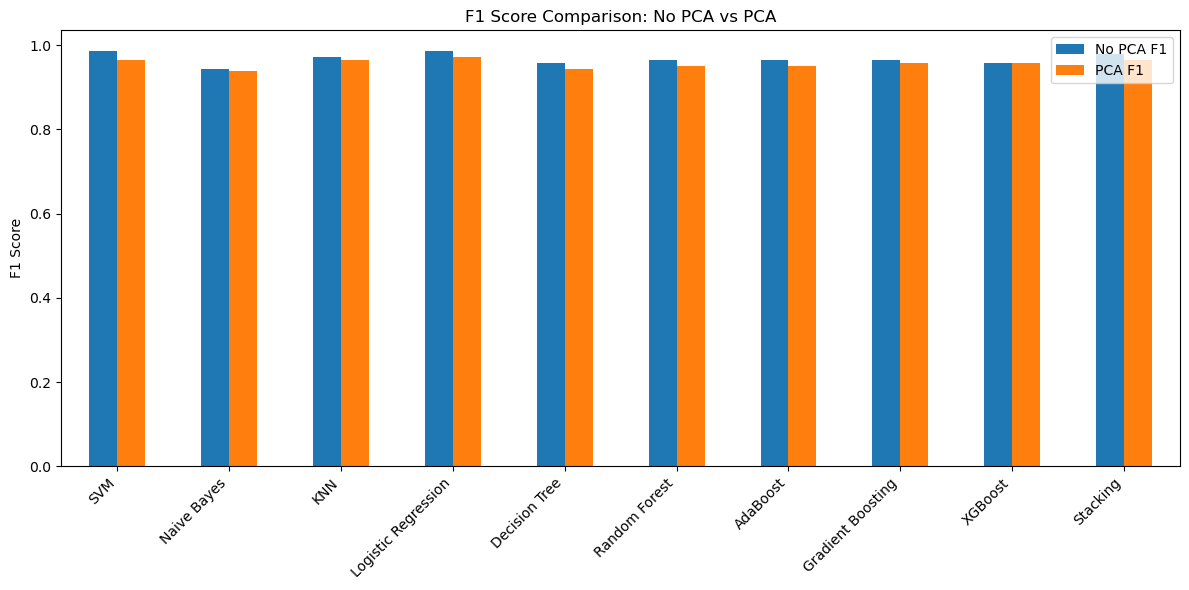

In [44]:
comparison[
    [
        "No PCA F1",
        "PCA F1"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.ylabel("F1 Score")
plt.title(
    "F1 Score Comparison: No PCA vs PCA"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

In [45]:
best_no_pca = (
    results_no_pca_df["F1 Score"]
    .idxmax()
)

print(
    "Best No-PCA model:",
    best_no_pca
)

print(
    "F1 Score:",
    results_no_pca_df.loc[
        best_no_pca,
        "F1 Score"
    ]
)

Best No-PCA model: SVM
F1 Score: 0.9861111111111112


In [46]:
best_pca = (
    results_pca_df["F1 Score"]
    .idxmax()
)

print(
    "Best PCA model:",
    best_pca
)

print(
    "F1 Score:",
    results_pca_df.loc[
        best_pca,
        "F1 Score"
    ]
)

Best PCA model: Logistic Regression
F1 Score: 0.971830985915493


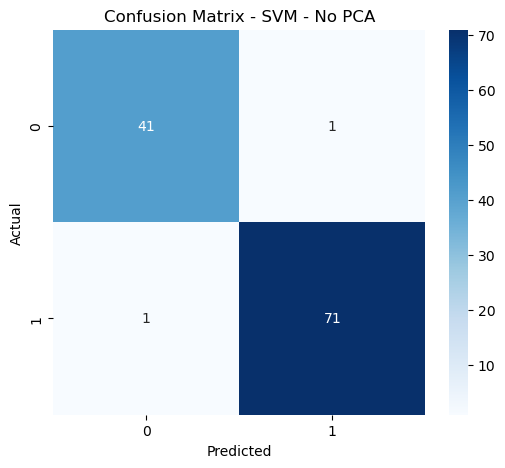

In [47]:
best_model_no_pca = (
    best_models_no_pca[best_no_pca]
)

y_pred_no_pca = (
    best_model_no_pca.predict(
        X_test_scaled
    )
)

cm = confusion_matrix(
    y_test,
    y_pred_no_pca
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    f"Confusion Matrix - {best_no_pca} - No PCA"
)

plt.show()

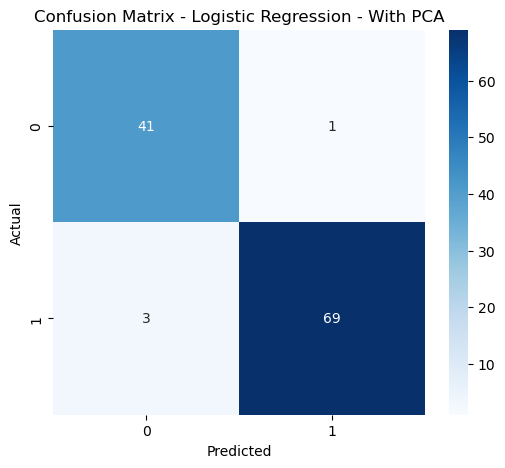

In [48]:
best_model_pca = (
    best_models_pca[best_pca]
)

y_pred_pca = (
    best_model_pca.predict(
        X_test_pca
    )
)

cm_pca = confusion_matrix(
    y_test,
    y_pred_pca
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_pca,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    f"Confusion Matrix - {best_pca} - With PCA"
)

plt.show()

In [49]:
print(
    classification_report(
        y_test,
        y_pred_no_pca,
        target_names=[
            "Malignant",
            "Benign"
        ]
    )
)

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [50]:
print(
    classification_report(
        y_test,
        y_pred_pca,
        target_names=[
            "Malignant",
            "Benign"
        ]
    )
)

              precision    recall  f1-score   support

   Malignant       0.93      0.98      0.95        42
      Benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



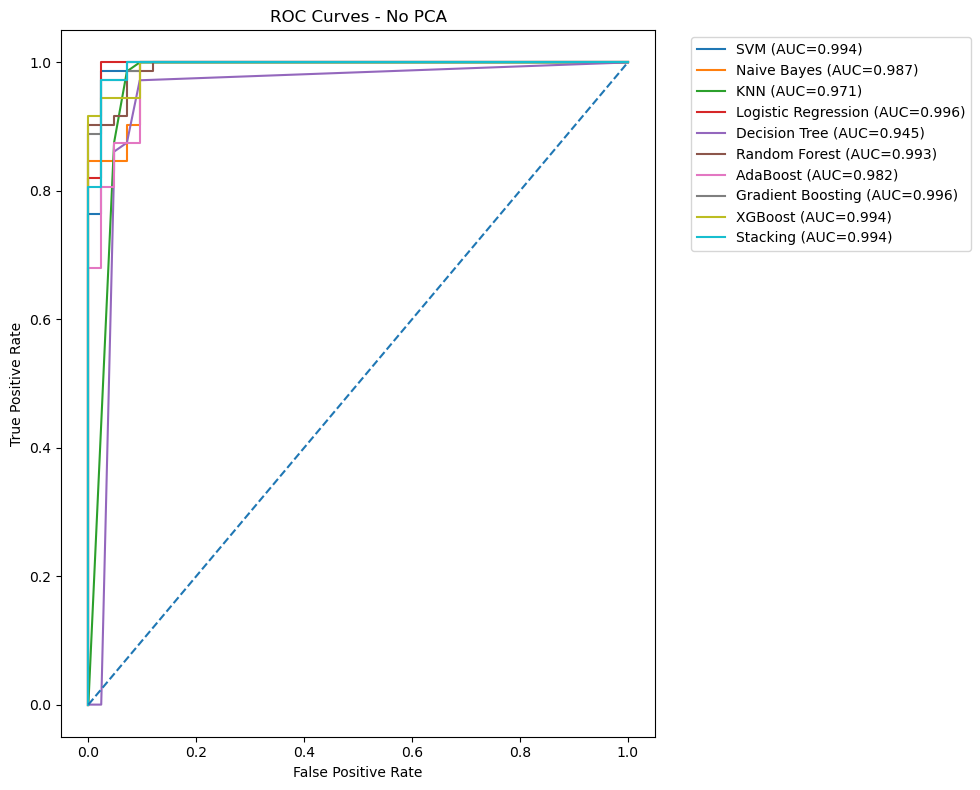

In [51]:
plt.figure(figsize=(10, 8))

for name, model in best_models_no_pca.items():

    if hasattr(model, "predict_proba"):

        y_score = model.predict_proba(
            X_test_scaled
        )[:, 1]

    else:

        y_score = model.decision_function(
            X_test_scaled
        )

    fpr, tpr, _ = roc_curve(
        y_test,
        y_score
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curves - No PCA")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

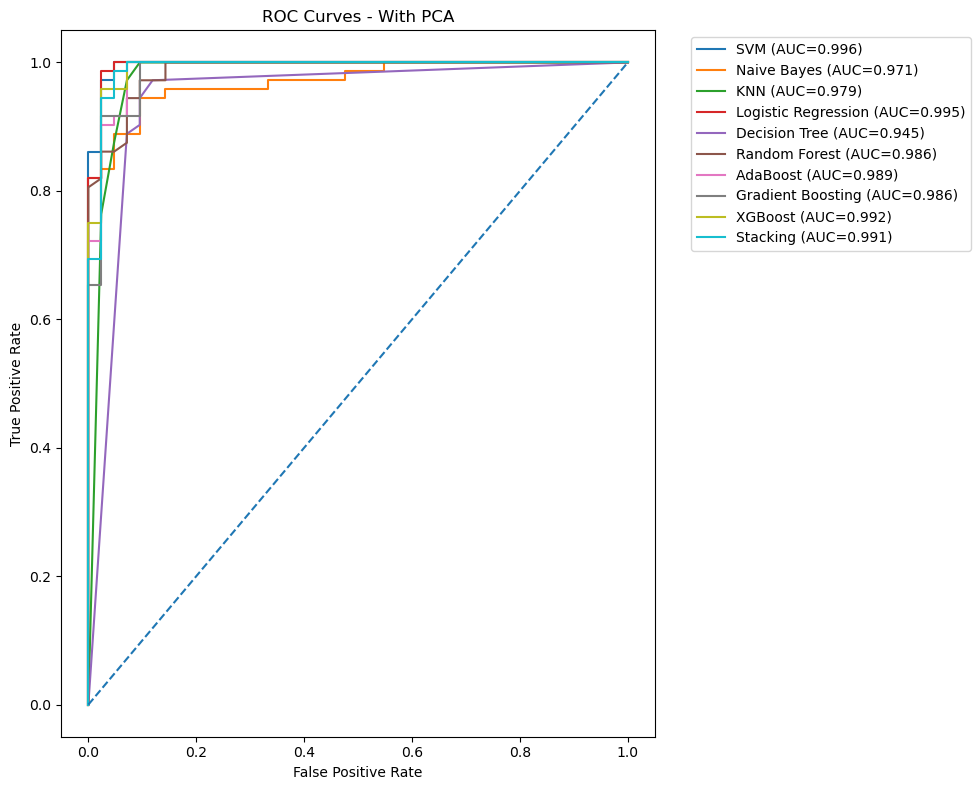

In [52]:
plt.figure(figsize=(10, 8))

for name, model in best_models_pca.items():

    if hasattr(model, "predict_proba"):

        y_score = model.predict_proba(
            X_test_pca
        )[:, 1]

    else:

        y_score = model.decision_function(
            X_test_pca
        )

    fpr, tpr, _ = roc_curve(
        y_test,
        y_score
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curves - With PCA")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

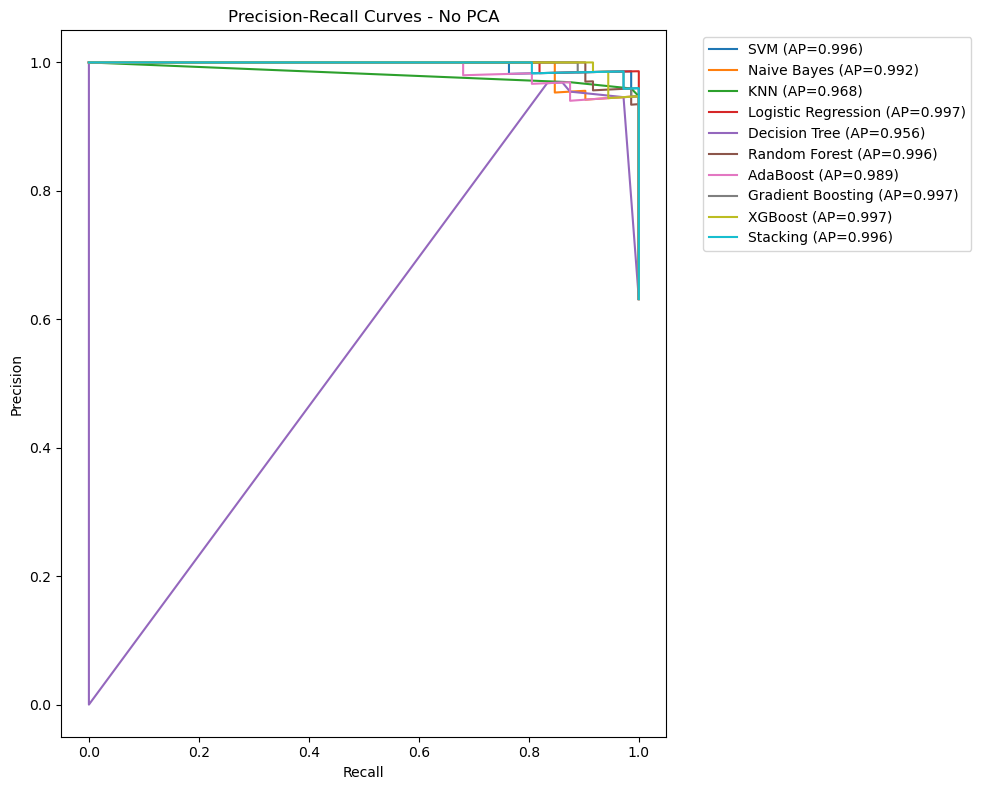

In [53]:
plt.figure(figsize=(10, 8))

for name, model in best_models_no_pca.items():

    if hasattr(model, "predict_proba"):

        y_score = model.predict_proba(
            X_test_scaled
        )[:, 1]

    else:

        y_score = model.decision_function(
            X_test_scaled
        )

    precision, recall, _ = (
        precision_recall_curve(
            y_test,
            y_score
        )
    )

    ap = average_precision_score(
        y_test,
        y_score
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} (AP={ap:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curves - No PCA"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

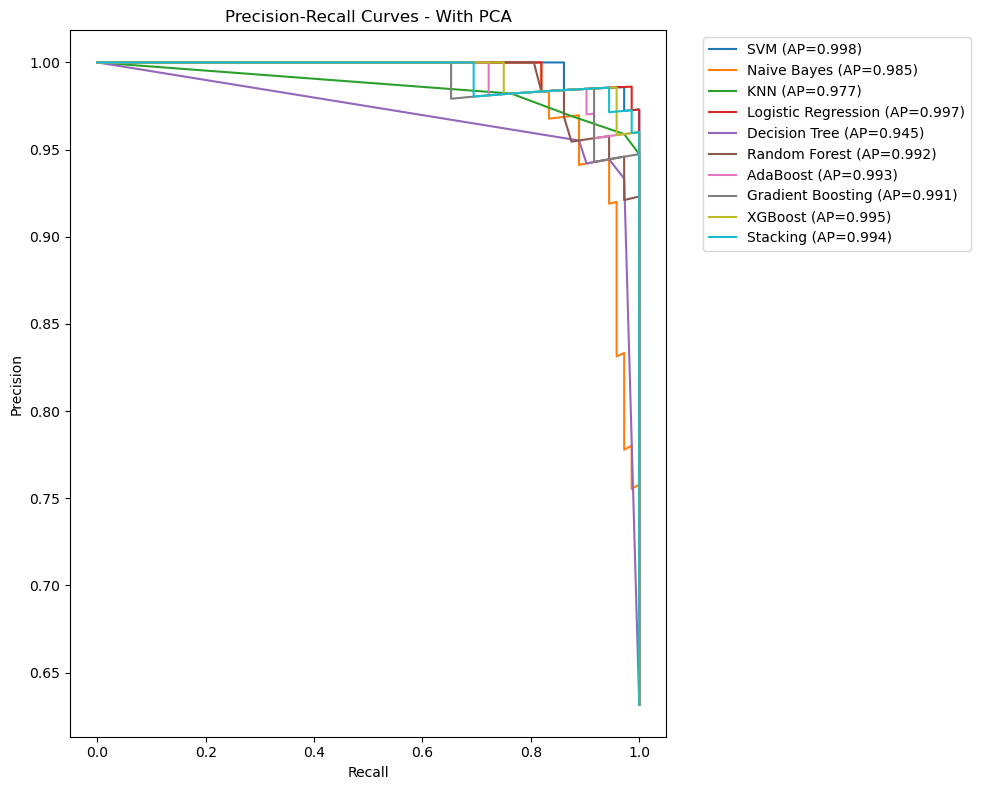

In [54]:
plt.figure(figsize=(10, 8))

for name, model in best_models_pca.items():

    if hasattr(model, "predict_proba"):

        y_score = model.predict_proba(
            X_test_pca
        )[:, 1]

    else:

        y_score = model.decision_function(
            X_test_pca
        )

    precision, recall, _ = (
        precision_recall_curve(
            y_test,
            y_score
        )
    )

    ap = average_precision_score(
        y_test,
        y_score
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} (AP={ap:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curves - With PCA"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

## Statistical Significance Testing: PCA vs No-PCA (Paired t-test & Wilcoxon Signed-Rank Test)

Both settings were evaluated on the **same 5 cross-validation folds** (same `cv` object, same `random_state`), so the F1 scores are *paired* observations rather than independent samples. This makes a **paired t-test** the natural parametric choice, and the **Wilcoxon signed-rank test** a robust non-parametric backup (useful since n=5 folds is a small sample, where normality is hard to verify).

- **Null hypothesis (H0):** there is no difference in mean F1 score between the No-PCA and PCA settings for a given model.
- **Alternative (H1):** there is a difference.
- We reject H0 at the conventional **alpha = 0.05** significance level.

In [55]:
from scipy import stats

alpha = 0.05

sig_results = []

for name in best_models_no_pca.keys():

    no_pca_f1 = np.array(cv_results_no_pca[name]["f1"])
    pca_f1 = np.array(cv_results_pca[name]["f1"])

    # Paired t-test: valid because both settings share the same CV folds
    t_stat, t_pvalue = stats.ttest_rel(no_pca_f1, pca_f1)

    # Wilcoxon signed-rank test: non-parametric alternative, robust to
    # the small sample size (5 folds) where normality can't be assumed.
    # zero_method="zsplit" avoids errors when a fold-wise difference is exactly 0.
    try:
        w_stat, w_pvalue = stats.wilcoxon(no_pca_f1, pca_f1, zero_method="zsplit")
    except ValueError:
        # Raised when all paired differences are zero
        w_stat, w_pvalue = np.nan, 1.0

    sig_results.append([
        name,
        np.mean(no_pca_f1),
        np.mean(pca_f1),
        np.mean(pca_f1) - np.mean(no_pca_f1),
        t_stat,
        t_pvalue,
        "Yes" if t_pvalue < alpha else "No",
        w_pvalue,
        "Yes" if w_pvalue < alpha else "No"
    ])

sig_df = pd.DataFrame(
    sig_results,
    columns=[
        "Model",
        "Mean F1 (No-PCA)",
        "Mean F1 (PCA)",
        "Mean Diff (PCA - No-PCA)",
        "t-statistic",
        "t-test p-value",
        "Significant (t-test)?",
        "Wilcoxon p-value",
        "Significant (Wilcoxon)?"
    ]
)

display(sig_df.round(4))


,Model,Mean F1 (No-PCA),Mean F1 (PCA),Mean Diff (PCA - No-PCA),t-statistic,t-test p-value,Significant (t-test)?,Wilcoxon p-value,Significant (Wilcoxon)?
0,SVM,0.9810,0.9845,0.0034,-1.6329,0.1778,No,0.5000,No
1,Naive Bayes,0.9478,0.9347,-0.0131,1.6070,0.1833,No,0.3125,No
2,KNN,0.9774,0.9724,-0.0050,1.5023,0.2074,No,0.5000,No
3,Logistic Regression,0.9842,0.9861,0.0019,-0.5676,0.6006,No,0.5000,No
4,Decision Tree,0.9464,0.9522,0.0058,-0.4876,0.6513,No,0.8125,No
5,Random Forest,0.9702,0.9687,-0.0015,0.4893,0.6503,No,0.7500,No
6,AdaBoost,0.9844,0.9622,-0.0222,3.4433,0.0262,Yes,0.0625,No
7,Gradient Boosting,0.9792,0.9720,-0.0071,0.8072,0.4648,No,0.6250,No
8,XGBoost,0.9772,0.9739,-0.0034,0.2854,0.7895,No,0.7500,No
9,Stacking,0.9772,0.9774,0.0002,-0.0574,0.9570,No,0.7500,No


### Interpretation

For each model, a "Yes" in the significance columns means the gap between the No-PCA and PCA F1 scores is unlikely to be due to random fold-to-fold variation, at the 5% significance level. A "No" means the observed difference could plausibly be noise, even if one mean looks higher than the other in the earlier CV table — this is the check that separates a real effect from a coincidence of the folds.

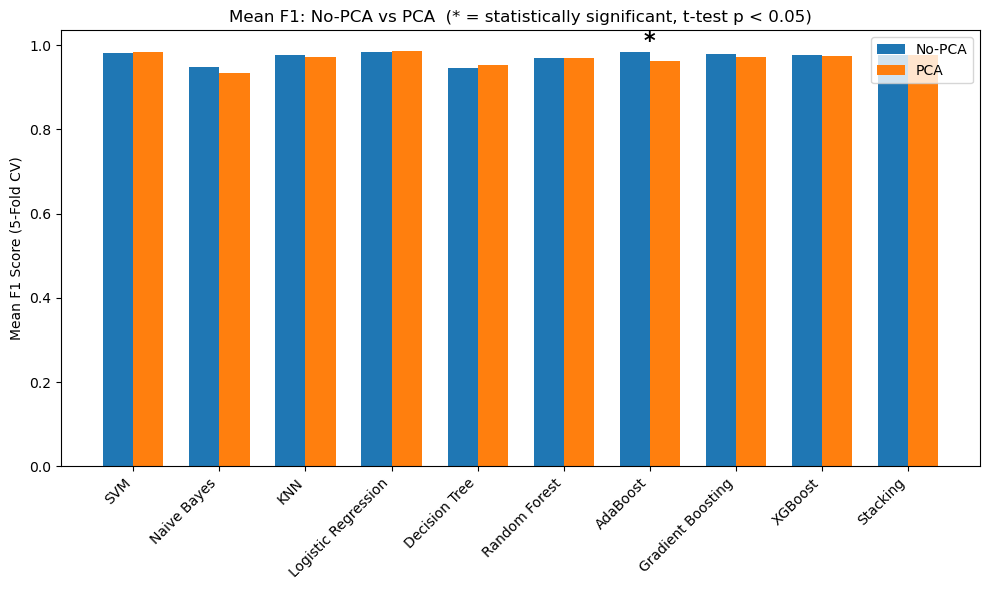

In [56]:
# Visual summary: highlight which PCA-vs-No-PCA differences are statistically significant

plt.figure(figsize=(10, 6))

x = np.arange(len(sig_df))
width = 0.35

bars1 = plt.bar(x - width/2, sig_df["Mean F1 (No-PCA)"], width, label="No-PCA")
bars2 = plt.bar(x + width/2, sig_df["Mean F1 (PCA)"], width, label="PCA")

# Mark models where the t-test found a significant difference
for i, sig in enumerate(sig_df["Significant (t-test)?"]):
    if sig == "Yes":
        y_max = max(sig_df["Mean F1 (No-PCA)"][i], sig_df["Mean F1 (PCA)"][i])
        plt.text(x[i], y_max + 0.01, "*", ha="center", fontsize=16, fontweight="bold")

plt.xticks(x, sig_df["Model"], rotation=45, ha="right")
plt.ylabel("Mean F1 Score (5-Fold CV)")
plt.title("Mean F1: No-PCA vs PCA  (* = statistically significant, t-test p < 0.05)")
plt.legend()
plt.tight_layout()
plt.show()
